In [1]:
import pandas as pd
import numpy as np
df = pd.read_parquet("yellow_tripdata_2025-01_clean.parquet")

In [2]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration,store_and_fwd_flag_Y
0,2,2025-01-01 00:18:38,2025-01-01 00:26:59,1.000000,1.60,1.0,229,237,1,10.0,...,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0,8.350000,0
1,2,2025-01-01 00:32:40,2025-01-01 00:35:13,1.000000,0.50,1.0,236,237,1,5.1,...,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0,2.550000,0
2,2,2025-01-01 00:44:04,2025-01-01 00:46:01,1.000000,0.60,1.0,141,141,1,5.1,...,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0,1.950000,0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,1.744647,0.52,1.0,244,244,1,7.2,...,0.5,0.00,0.0,1.0,9.70,2.5,0.0,0.0,5.566667,0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,1.744647,0.66,1.0,244,116,1,5.8,...,0.5,0.00,0.0,1.0,8.30,2.5,0.0,0.0,3.533333,0


In [3]:
df.shape

(3475226, 21)

In [4]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
Airport_fee              0
cbd_congestion_fee       0
trip_duration            0
store_and_fwd_flag_Y     0
dtype: int64

# UNIVARIATE ANALYSIS
Questions
What is the distribution of trip duration?
What is the distribution of trip distance?

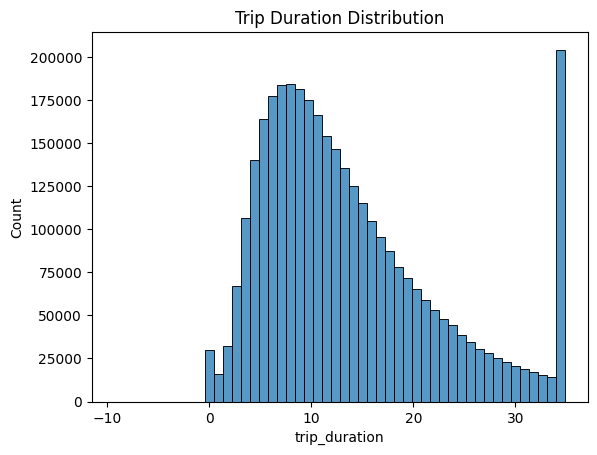

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['trip_duration'], bins=50)
plt.title("Trip Duration Distribution")
plt.show()


In [ ]:
The largest trip last long over 35 mins. Majority of the trip between 5mins and 15 mins.

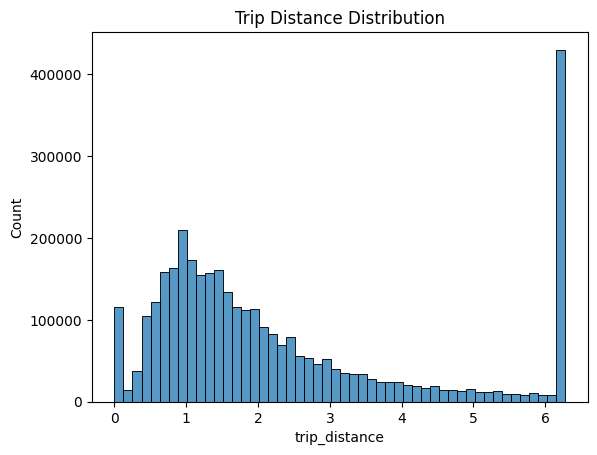

In [6]:
sns.histplot(df['trip_distance'], bins=50)
plt.title("Trip Distance Distribution")
plt.show()

In the above graph trip_distance over 6 miles has the large amount of trip. Majority of the trips 0.5 miles to 2 miles.


# BIVARIATE ANALYSIS
Questions
How does distance impact duration?
Is fare proportional to distance?

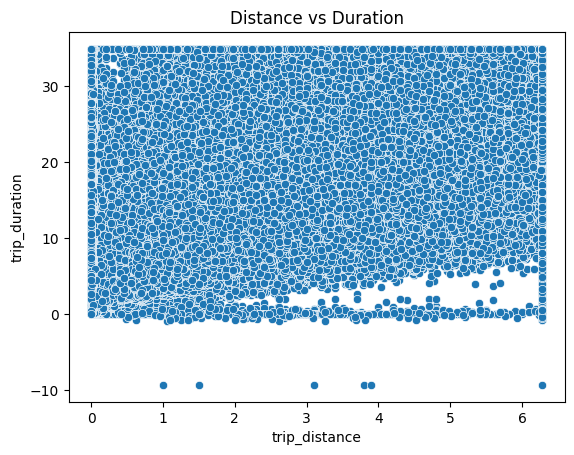

In [7]:
sns.scatterplot(x='trip_distance', y='trip_duration', data=df)
plt.title("Distance vs Duration")
plt.show()


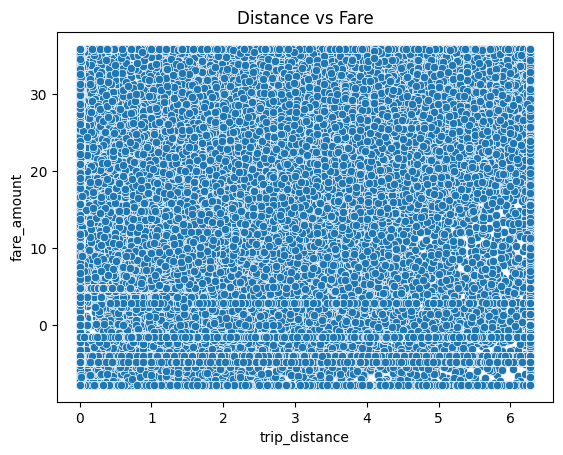

In [8]:
sns.scatterplot(x='trip_distance', y='fare_amount', data=df)
plt.title("Distance vs Fare")
plt.show()


# TIME-BASED ANALYSIS
Questions
When is peak demand?
Which hours have highest trips?

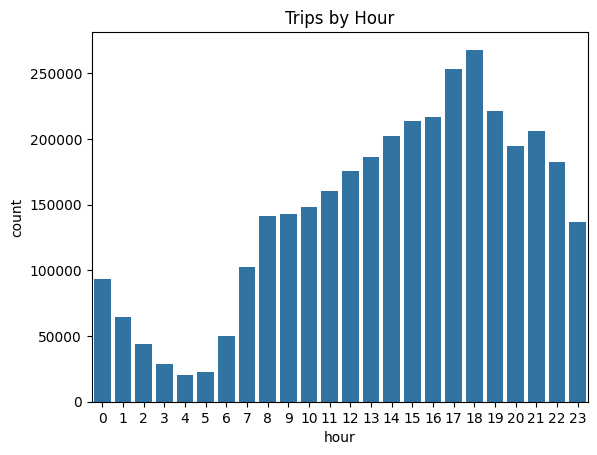

In [9]:
df['hour'] = df['tpep_pickup_datetime'].dt.hour

sns.countplot(x='hour', data=df)
plt.title("Trips by Hour")
plt.show()

Based on above graphe most of the trips happened between 5 pm and 8 pm

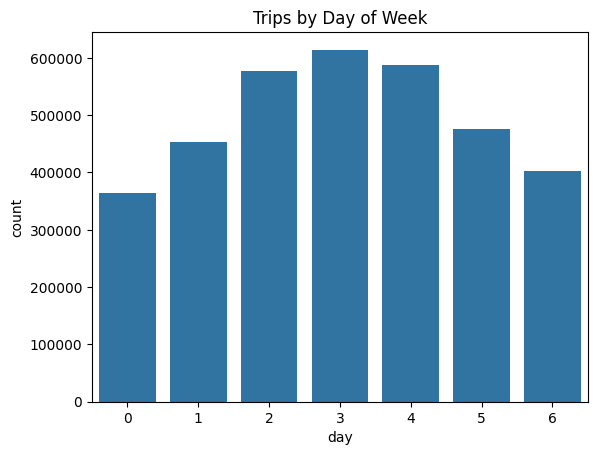

In [10]:
#Day of Week
df['day'] = df['tpep_pickup_datetime'].dt.dayofweek

sns.countplot(x='day', data=df)
plt.title("Trips by Day of Week")
plt.show()

In [ ]:
Based on above graphe most of the trips happened of mid week. Weekends are lowest amount of trips.



# SPEED / EFFICIENCY ANALYSIS
Questions
Are trips efficient?
Are there slow routes?

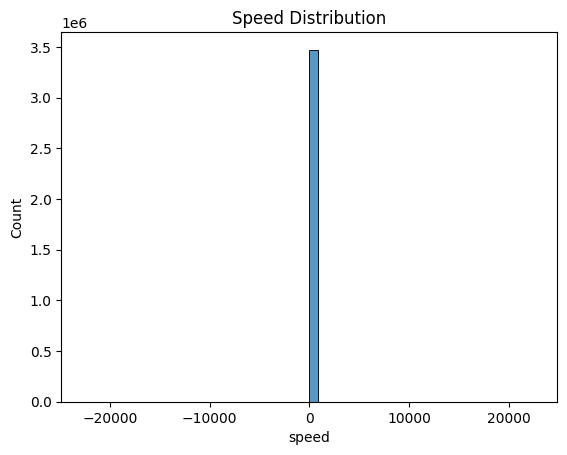

In [11]:
df['speed'] = df['trip_distance'] / (df['trip_duration']/60)

sns.histplot(df['speed'], bins=50)
plt.title("Speed Distribution")
plt.show()



# LOCATION ANALYSIS (HOTSPOTS)
Questions
Where are most pickups happening?

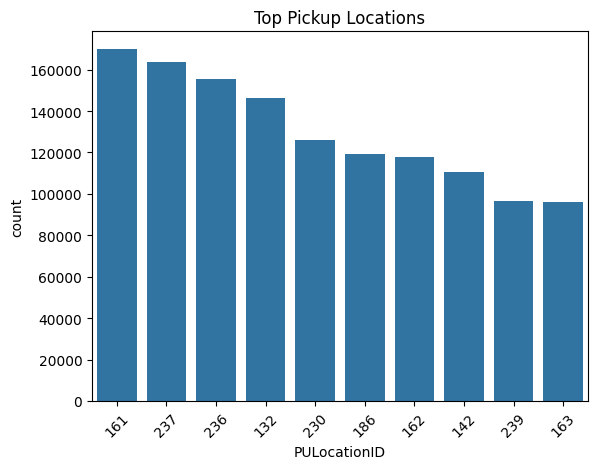

In [12]:
sns.countplot(x='PULocationID', data=df, order=df['PULocationID'].value_counts().index[:10])
plt.title("Top Pickup Locations")
plt.xticks(rotation=45)
plt.show()



# OUTLIER DETECTION
Questions
Are there extreme values affecting model?

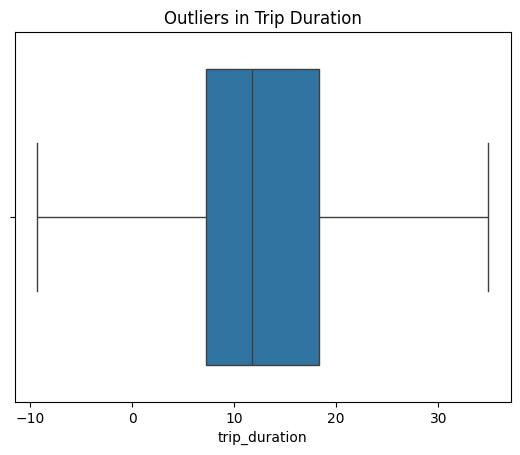

In [13]:
sns.boxplot(x=df['trip_duration'])
plt.title("Outliers in Trip Duration")
plt.show()

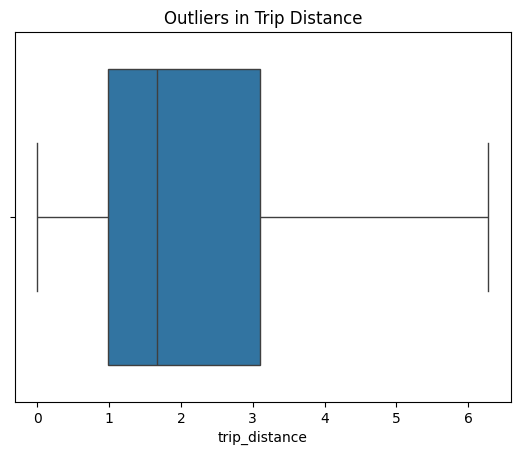

In [14]:
sns.boxplot(x=df['trip_distance'])
plt.title("Outliers in Trip Distance")
plt.show()

# CORRELATION ANALYSIS
Questions
Trip distance and duration impact fare_amount?

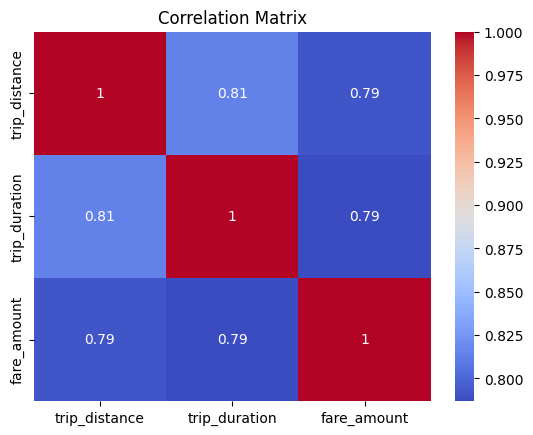

In [15]:
corr = df[['trip_distance','trip_duration','fare_amount']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()